In [1]:
import pandas as pd

fn = "des_smiles.csv"
df = pd.read_csv(fn, sep=";")
df

,Isomeric_Smiles,End_Point
0,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.7
1,COc1cccc([C@@H](C)NC(c2ccc(cc2)-c2ccncn2)=O)c1,5.4
2,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.9
3,O=C(c1ccc(cc1)-c1ncncc1)N[C@@H](c1cc(OC)ccc1)C,5.1
4,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.7
...,...,...
995,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncc3)cc2)c1,5.5
996,c1cc(cc([C@@H](C)NC(c2ccc(cc2)-c2ccncc2)=O)c1)OC,7.8
997,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncc3)cc2)c1,6.2
998,Cn1c(=O)c(Oc2ccc(F)cc2F)cc2cnc(NC3CCOCC3)nc21,5.0


# 1. 몇 개의 Isomeric Smiles가 있는지 구하기.

In [2]:
num_molecules = len(df)
print(f"전체 분자 개수: {num_molecules}개")
df.head()

전체 분자 개수: 1000개


,Isomeric_Smiles,End_Point
0,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.7
1,COc1cccc([C@@H](C)NC(c2ccc(cc2)-c2ccncn2)=O)c1,5.4
2,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.9
3,O=C(c1ccc(cc1)-c1ncncc1)N[C@@H](c1cc(OC)ccc1)C,5.1
4,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.7


# 2. Isomeric Smiles 중에 duplicate이 얼마나 있는지 구하기.

In [3]:
from rdkit import Chem
unique_count = df['Isomeric_Smiles'].nunique()
duplicated_count = num_molecules - unique_count

print(f"전체 개수 : {num_molecules}")
print(f"중복 개수 : {duplicated_count}")
print(f"Unique 개수 : {unique_count}")

전체 개수 : 1000
중복 개수 : 340
Unique 개수 : 660


# 3. 각각의 Isomeric Smiles를 Canonical Smiles로 변환하고 그 smiles를 새로운 column에 추가.

In [4]:
def to_canonical(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Chem.MolToSmiles(mol, isomericSmiles=True, canonical=True)# somericSmiles=False로 설정하여 입체 정보를 제외한 표준 구조를 얻거나,
        # 기본값(True)을 사용하여 입체 정보를 포함한 표준 구조를 얻을 수 있다.. 우린 기본값으로 일반적인 중복값 제거ㅓ 
    return None

# canonical smiles column  추가 
df['Canonical_Smiles'] = df['Isomeric_Smiles'].apply(to_canonical)

# 3. 기존 Isomeric_Smiles와 Canonical_Smiles 비교 출력

diff_df = df[df['Isomeric_Smiles'] != df['Canonical_Smiles']]
print(f"표기법이 달라진 분자 수: {len(diff_df)}개")
df[['Isomeric_Smiles', 'Canonical_Smiles', 'End_Point']].head()


표기법이 달라진 분자 수: 400개


,Isomeric_Smiles,Canonical_Smiles,End_Point
0,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.7
1,COc1cccc([C@@H](C)NC(c2ccc(cc2)-c2ccncn2)=O)c1,COc1cccc([C@@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.4
2,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.9
3,O=C(c1ccc(cc1)-c1ncncc1)N[C@@H](c1cc(OC)ccc1)C,COc1cccc([C@@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.1
4,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,COc1cccc([C@H](C)NC(=O)c2ccc(-c3ccncn3)cc2)c1,5.7


# 4. Canonical Smiles 기준으로 duplicate의 개수를 구하고 그림으로 표현.
#### 아래는 그림 그리기 위한 라이브러리 설치 명령어
#### ※ 반드시 Mordred 가상환경에서 실행해야 함.
#### pip install matplotlib-venn

In [5]:
from rdkit import Chem
num_total = len(df)
num_unique_canonical = df['Canonical_Smiles'].nunique()
num_duplicates_canonical = num_total - num_unique_canonical

print(f"전체 개수: {num_total}")
print(f"중복 개수 : {num_duplicates_canonical}")
print(f"Unique 개수: {num_unique_canonical}")

전체 개수: 1000
중복 개수 : 659
Unique 개수: 341


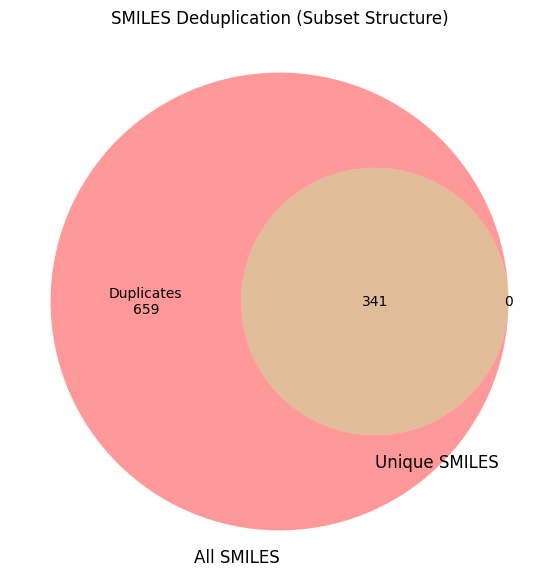

In [6]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
# 데이터 계산 
num_total = len(df) # 전체 개수 (1000)
num_unique = df['Canonical_Smiles'].nunique() # Unique 개수 ( 결과: 341) 
num_duplicates = num_total - num_unique # 중복 개수 ( 결과: 659) 

#  시각화 설정
plt.figure(figsize=(7, 7))

# subsets=(Ab, aB, AB) 설정 논리:
# Ab (왼쪽 원에만 해당): 전체에서 고유값을 뺀 'Duplicates' 영역 
# aB (오른쪽 원에만 해당): 고유값 중 전체에 포함 안 되는 것은 없으므로 '0'
v = venn2(subsets=(num_duplicates, 0, num_unique), 
          set_labels=('All SMILES', 'Unique SMILES'))


if v.get_label_by_id('10'): 
    v.get_label_by_id('10').set_text(f'Duplicates\n{num_duplicates}') # 'Duplicates 739' 형태 
if v.get_label_by_id('11'): 
    v.get_label_by_id('11').set_text(f'{num_unique}') # '261' 형태 
if v.get_label_by_id('01'): 
    v.get_label_by_id('01').set_text('0') # '0' 형태 

plt.title("SMILES Deduplication (Subset Structure)") 
plt.show()

# 5. Isomeric Smiles Column 제거, Canonical_Smiles duplicate 제거.
#### 여러개의 같은 Canonical Smiles의 End_Point 값을 평균 내서 새로운 End_Point에 넣기.
#### ex)  c1_smiles  4.0
####      c2_smiles  5.0
####      c3_smiles  6.0
#### 이런 경우에는  "c_smiles  5.0"  이렇게 입력이 되도록

In [7]:
#  Isomeric_Smiles 컬럼 제거
df_refined = df.drop(columns=['Isomeric_Smiles'])

#  Canonical_Smiles 기준으로 그룹화하고 End_Point 평균 계산
# 이 과정에서 그룹화를 하니 자동으로 Canonical_Smiles의 중복이 제거
df_final = df_refined.groupby('Canonical_Smiles')['End_Point'].mean().reset_index()

# 3. 결과 확인
print(f"제거 전 행 개수: {len(df)}")
print(f"제거 후 행 개수: {len(df_final)}")
df_final

제거 전 행 개수: 1000
제거 후 행 개수: 341


,Canonical_Smiles,End_Point
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,5.000
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,5.400
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,5.175
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,5.200
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,5.150
...,...,...
336,Oc1nn2ccccc2c1Br,5.550
337,c1ccc(-c2c[nH]c3ncnc(N4CCCCC4)c23)cc1,5.200
338,c1ccc(COc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.000
339,c1ccc(CSc2nc(-c3ccncc3)n[nH]2)cc1,5.100


# 6. Duplicate 제거한 Canonical Smiles를 이용하여 모든 RDKit Descriptor를 계산하고 그 결과를 dataframe 만들기. 그리고 총 몇 개의 descriptor가 계산 되었는지 출력.

In [8]:
from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np
from tqdm import tqdm


# 모든 RDKit Descriptor 리스트 가져오기
all_descriptors = [d[0] for d in Descriptors._descList]

# 2. 기술자 계산 함수 정의
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        results = {}
        for name, func in Descriptors._descList:
            results[name] = func(mol)
        return results
    return {name: None for name in all_descriptors}

# 3. 진행 상황을 확인하며 계산 수행 (tqdm 사용)
print("RDKit Descriptor 계산 중")
desc_data = []
for smiles in tqdm(df_final['Canonical_Smiles']):
    desc_data.append(calculate_descriptors(smiles))

# 4. 결과를 데이터프레임으로 변환 및 병합
df_descriptors = pd.DataFrame(desc_data)
# 인덱스 유지를 위해 df_final과 옆으로 합치기
df_rdkit = pd.concat([df_final[['Canonical_Smiles']], df_descriptors], axis=1)

# 5. 총 기술자 개수 출력
print(f"RDKit Descriptor 개수 : {len(all_descriptors)}")
print(f"데이터프레임 크기: {df_rdkit.shape}")
df_rdkit.head()

RDKit Descriptor 계산 중


100%|████████████████████████████████████████| 341/341 [00:02<00:00, 150.60it/s]

RDKit Descriptor 개수 : 123
데이터프레임 크기: (341, 124)


,Canonical_Smiles,MaxEStateIndex,MinEStateIndex,MaxAbsEStateIndex,MinAbsEStateIndex,qed,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,NumHAcceptors,NumHDonors,NumHeteroatoms,NumRotatableBonds,NumSaturatedCarbocycles,NumSaturatedHeterocycles,NumSaturatedRings,RingCount,MolLogP,MolMR
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,8.868717,0.386681,8.868717,0.386681,0.577516,312.332,300.236,312.101111,114,...,4,1,5,2,0,0,0,4,2.90448,89.2627
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,5.899105,0.260396,5.899105,0.260396,0.923655,267.332,250.196,267.137162,102,...,4,1,4,4,0,1,1,3,2.38770,79.3047
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,5.899105,0.260396,5.899105,0.260396,0.923655,267.332,250.196,267.137162,102,...,4,1,4,4,0,1,1,3,2.38770,79.3047
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,4.405655,0.631751,4.405655,0.631751,0.395491,275.315,262.211,275.117095,102,...,3,3,5,3,0,0,0,4,3.49020,85.6091
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,12.725354,-0.563857,12.725354,0.014559,0.392870,378.352,364.240,378.118886,140,...,10,2,11,5,0,0,0,4,1.64650,97.4486


# 7-1. RDKit에서 Morgan Fingerprint 계산하기
### radius 값과 nBits 값을 변화 시키면서 몇 bit 까지 만들 수 있는지 test

In [9]:
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.DataStructs import ConvertToNumpyArray
import numpy as np
import pandas as pd
from tqdm import tqdm

# 테스트 
nBits = 1024
radius = 2

fps_list = []
print(f"Morgan Fingerprint 계산 중 (Bits: {nBits}, Radius: {radius})...")

for smiles in tqdm(df_final['Canonical_Smiles']):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        #  Morgan Fingerprint 비트 벡터 생성
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius=radius, nBits=nBits)
        
        #  ConvertToNumpyArray를 사용하기 위한 빈 배열 생성
        arr = np.zeros((nBits,), dtype=int)
        
        #  비트 정보를 넘파이 배열로 복사
        ConvertToNumpyArray(fp, arr)
        fps_list.append(arr)
    else:
        fps_list.append(np.zeros((nBits,), dtype=int))

# 4. 데이터프레임 생성 (MorganFP_0 ~ MorganFP_1023)
col_names = [f'MorganFP_{i}' for i in range(nBits)]
df_morgan = pd.DataFrame(fps_list, columns=col_names)

# 5. Canonical_Smiles와 결합 
df_morgan_final = pd.concat([df_final[['Canonical_Smiles']], df_morgan], axis=1)

print(f"최종 데이터프레임 크기: {df_morgan_final.shape}")
df_morgan_final.head()

Morgan Fingerprint 계산 중 (Bits: 1024, Radius: 2)...


100%|███████████████████████████████████████| 341/341 [00:00<00:00, 5867.34it/s]

최종 데이터프레임 크기: (341, 1025)


,Canonical_Smiles,MorganFP_0,MorganFP_1,MorganFP_2,MorganFP_3,MorganFP_4,MorganFP_5,MorganFP_6,MorganFP_7,MorganFP_8,...,MorganFP_1014,MorganFP_1015,MorganFP_1016,MorganFP_1017,MorganFP_1018,MorganFP_1019,MorganFP_1020,MorganFP_1021,MorganFP_1022,MorganFP_1023
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0


# 7-2. RDKit에서 MACCS fingerprint 계산하기

In [10]:
from rdkit.Chem import MACCSkeys
from rdkit.DataStructs import ConvertToNumpyArray
import numpy as np
import pandas as pd
from tqdm import tqdm

# MACCS 키는 167비트 고정, 별도의 nBits 설정이 필요 없음
maccs_fps = []

print("MACCS Fingerprint 계산 중...")
for smiles in tqdm(df_final['Canonical_Smiles']):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        # MACCS keys 생성
        fp = MACCSkeys.GenMACCSKeys(mol)
        
        # 넘파이 배열로 변환 (RDKit MACCS는 167비트
        arr = np.zeros((fp.GetNumBits(),), dtype=int)
        ConvertToNumpyArray(fp, arr)
        maccs_fps.append(arr)
    else:
        maccs_fps.append(np.zeros((167,), dtype=int))

# 3. 데이터프레임 생성 (MACCS_0 ~ MACCS_166)
col_names = [f'MACCS_{i}' for i in range(167)]
df_maccs = pd.DataFrame(maccs_fps, columns=col_names)

# 4. Canonical_Smiles와 병합
df_maccs_final = pd.concat([df_final[['Canonical_Smiles']], df_maccs], axis=1)

print(f"최종 데이터프레임 크기: {df_maccs_final.shape}")
df_maccs_final.head()

MACCS Fingerprint 계산 중...


100%|███████████████████████████████████████| 341/341 [00:00<00:00, 1274.04it/s]

최종 데이터프레임 크기: (341, 168)


,Canonical_Smiles,MACCS_0,MACCS_1,MACCS_2,MACCS_3,MACCS_4,MACCS_5,MACCS_6,MACCS_7,MACCS_8,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,0,0,0,0,0,0,0,0,0,...,1,0,0,1,1,1,1,1,1,0
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,1,1,1,0
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,0,0,0,0,0,0,0,0,0,...,1,1,0,0,1,1,1,1,1,0
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,1,1,0,1,0
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,0,0,0,0,0,0,0,0,0,...,0,1,1,1,1,1,1,1,1,0


# 8. Mordred Descriptor 계산하기
### 총 몇 개의 2D descriptor가 계산되는지 확인

In [11]:

from mordred import Calculator, descriptors
from rdkit import Chem
import pandas as pd

#  Mordred 계산기 초기화 (2D 기술자만 사용하도록 ignore_3D=True 설정)
calc = Calculator(descriptors, ignore_3D=True)

# SMILES 리스트를 RDKit Mol 객체 리스트로 변환
mols = [Chem.MolFromSmiles(s) for s in df_final['Canonical_Smiles']]

# 기술자 계산 (pandas 데이터프레임 형태로 직접 반환)
print(f"Mordred 2D 기술자 계산 시작 (대상 분자: {len(mols)}개)...")
df_mordred_raw = calc.pandas(mols)

# Canonical_Smiles 컬럼 추가 및 정리
df_mordred_raw.insert(0, 'Canonical_Smiles', df_final['Canonical_Smiles'].values)

print(f"계산된 2D Descriptor 총 개수 : {len(calc.descriptors)}개")
print(f"최종 데이터프레임 크기: {df_mordred_raw.shape}")
df_mordred_raw.head()

Mordred 2D 기술자 계산 시작 (대상 분자: 341개)...


100%|█████████████████████████████████████████| 341/341 [00:40<00:00,  8.42it/s]


계산된 2D Descriptor 총 개수 : 1613개
최종 데이터프레임 크기: (341, 1614)


,Canonical_Smiles,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,18.849242,15.034433,0,0,32.077631,2.557420,4.913099,32.077631,1.336568,...,10.252911,75.234647,312.101111,8.669475,1347,41,132.0,162.0,7.000000,5.416667
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,1.342886,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,1.342886,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,16.849242,13.107364,0,0,28.593773,2.405085,4.653779,28.593773,1.361608,...,9.916848,70.967206,275.117095,8.091679,1050,29,114.0,135.0,4.416667,4.583333
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,21.965399,18.997252,0,0,37.057961,2.496435,4.862435,37.057961,1.323499,...,10.184636,80.108735,378.118886,9.002831,2065,41,148.0,176.0,8.000000,6.194444


# 9. Mordred 계산 결과에서 Non-Numerical 값이 있는 column 제거

In [12]:
import pandas as pd
import numpy as np

#  Canonical_Smiles를 제외한 기술자 컬럼만 선택하여 수치형 변환
# errors='coerce' 옵션을 통해 Non-numerical 값을 NaN으로 
df_numeric_temp = df_mordred_raw.drop(columns=['Canonical_Smiles']).apply(pd.to_numeric, errors='coerce')

#  NaN이 하나라도 포함된 컬럼(즉, 원래 비수치값이 있었던 컬럼) 식별
cols_with_nan = df_numeric_temp.columns[df_numeric_temp.isna().any()].tolist()

# 해당 컬럼 제거
df_mordred_numeric_only = df_numeric_temp.dropna(axis=1)

# Canonical_Smiles 컬럼과 다시 병합
df_step9 = pd.concat([df_mordred_raw[['Canonical_Smiles']], df_mordred_numeric_only], axis=1)

#  결과 출력
print(f"Non-Numerical Column 개수: {len(cols_with_nan)}")
print(f"제거된 컬럼 목록: {cols_with_nan}")
print(f"최종 데이터프레임 크기: {df_step9.shape}")
df_step9.head()

Non-Numerical Column 개수: 233
제거된 컬럼 목록: ['AATS8dv', 'AATS8d', 'AATS8s', 'AATS8Z', 'AATS8m', 'AATS8v', 'AATS8se', 'AATS8pe', 'AATS8are', 'AATS8p', 'AATS8i', 'AATSC8c', 'AATSC8dv', 'AATSC8d', 'AATSC8s', 'AATSC8Z', 'AATSC8m', 'AATSC8v', 'AATSC8se', 'AATSC8pe', 'AATSC8are', 'AATSC8p', 'AATSC8i', 'MATS8c', 'MATS8dv', 'MATS8d', 'MATS8s', 'MATS8Z', 'MATS8m', 'MATS8v', 'MATS8se', 'MATS8pe', 'MATS8are', 'MATS8p', 'MATS8i', 'GATS8c', 'GATS8dv', 'GATS8d', 'GATS8s', 'GATS8Z', 'GATS8m', 'GATS8v', 'GATS8se', 'GATS8pe', 'GATS8are', 'GATS8p', 'GATS8i', 'SpAbs_Dt', 'SpMax_Dt', 'SpDiam_Dt', 'SpAD_Dt', 'SpMAD_Dt', 'LogEE_Dt', 'SM1_Dt', 'VE1_Dt', 'VE2_Dt', 'VE3_Dt', 'VR1_Dt', 'VR2_Dt', 'VR3_Dt', 'DetourIndex', 'MAXsLi', 'MAXssBe', 'MAXssssBe', 'MAXssBH', 'MAXsssB', 'MAXssssB', 'MAXsCH3', 'MAXdCH2', 'MAXssCH2', 'MAXtCH', 'MAXdsCH', 'MAXsssCH', 'MAXddC', 'MAXtsC', 'MAXdssC', 'MAXaaaC', 'MAXssssC', 'MAXsNH3', 'MAXsNH2', 'MAXssNH2', 'MAXdNH', 'MAXssNH', 'MAXaaNH', 'MAXtN', 'MAXsssNH', 'MAXdsN', 'MAXaaN', 'MAX

,Canonical_Smiles,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,18.849242,15.034433,0,0,32.077631,2.557420,4.913099,32.077631,1.336568,...,10.252911,75.234647,312.101111,8.669475,1347,41,132.0,162.0,7.000000,5.416667
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,1.342886,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,1.342886,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,16.849242,13.107364,0,0,28.593773,2.405085,4.653779,28.593773,1.361608,...,9.916848,70.967206,275.117095,8.091679,1050,29,114.0,135.0,4.416667,4.583333
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,21.965399,18.997252,0,0,37.057961,2.496435,4.862435,37.057961,1.323499,...,10.184636,80.108735,378.118886,9.002831,2065,41,148.0,176.0,8.000000,6.194444


# 10. 위 dataframe 에서 한 column의 값들이 모두 같은 경우를 제거.

In [13]:
#  각 컬럼별 고유값(Unique value) 개수 확인
# nunique()가 1인 컬럼은 모든 행의 값이 같다는 뜻..
cols_all_same = [col for col in df_step9.columns if df_step9[col].nunique() <= 1]

# 고정값 컬럼을 제외한 나머지 컬럼만 선택
df_step10 = df_step9.drop(columns=cols_all_same)

#  결과 출력
print(f"All same value Column 개수: {len(cols_all_same)}")
print(f"제거된 컬럼 목록: {cols_all_same}") 
print(f"최종 데이터프레임 크기: {df_step10.shape}")
df_step10.head()

All same value Column 개수: 159
제거된 컬럼 목록: ['nSpiro', 'nB', 'nP', 'NsLi', 'NssBe', 'NssssBe', 'NssBH', 'NsssB', 'NssssB', 'NdCH2', 'NddC', 'NsNH3', 'NssNH2', 'NsssNH', 'NssssN', 'NsSiH3', 'NssSiH2', 'NsssSiH', 'NssssSi', 'NsPH2', 'NssPH', 'NsssP', 'NdsssP', 'NsssssP', 'NsSH', 'NsGeH3', 'NssGeH2', 'NsssGeH', 'NssssGe', 'NsAsH2', 'NssAsH', 'NsssAs', 'NsssdAs', 'NsssssAs', 'NsSeH', 'NdSe', 'NssSe', 'NaaSe', 'NdssSe', 'NddssSe', 'NsSnH3', 'NssSnH2', 'NsssSnH', 'NssssSn', 'NsPbH3', 'NssPbH2', 'NsssPbH', 'NssssPb', 'SsLi', 'SssBe', 'SssssBe', 'SssBH', 'SsssB', 'SssssB', 'SdCH2', 'SddC', 'SsNH3', 'SssNH2', 'SsssNH', 'SssssN', 'SsSiH3', 'SssSiH2', 'SsssSiH', 'SssssSi', 'SsPH2', 'SssPH', 'SsssP', 'SdsssP', 'SsssssP', 'SsSH', 'SsGeH3', 'SssGeH2', 'SsssGeH', 'SssssGe', 'SsAsH2', 'SssAsH', 'SsssAs', 'SsssdAs', 'SsssssAs', 'SsSeH', 'SdSe', 'SssSe', 'SaaSe', 'SdssSe', 'SddssSe', 'SsSnH3', 'SssSnH2', 'SsssSnH', 'SssssSn', 'SsPbH3', 'SssPbH2', 'SsssPbH', 'SssssPb', 'ETA_dPsi_B', 'SMR_VSA8', 'SlogP_VSA9'

,Canonical_Smiles,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,SpMAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,18.849242,15.034433,0,0,32.077631,2.557420,4.913099,32.077631,1.336568,...,10.252911,75.234647,312.101111,8.669475,1347,41,132.0,162.0,7.000000,5.416667
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,1.342886,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,1.342886,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,16.849242,13.107364,0,0,28.593773,2.405085,4.653779,28.593773,1.361608,...,9.916848,70.967206,275.117095,8.091679,1050,29,114.0,135.0,4.416667,4.583333
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,21.965399,18.997252,0,0,37.057961,2.496435,4.862435,37.057961,1.323499,...,10.184636,80.108735,378.118886,9.002831,2065,41,148.0,176.0,8.000000,6.194444


# 11. Filtering이 완료된 dataframe에서 column 별 variance를 계산하고 그 결과를 Histogram으로 표시.

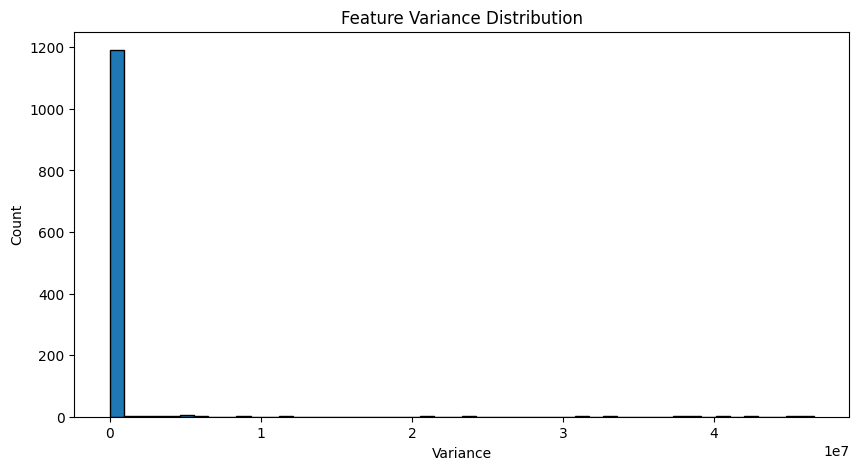

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# 분산계산 (문자열인 Canonical_Smiles 컬럼은 제외)
variances = df_step10.drop(columns=['Canonical_Smiles']).var()

#   히스토그램 출력 
# 대부분의 분산이 0 근처에 몰려 있어 분포 파악이 어렵
plt.figure(figsize=(10, 5))
plt.hist(variances, bins=50, edgecolor='black', log=False)
plt.title("Feature Variance Distribution")
plt.xlabel("Variance")
plt.ylabel("Count")
plt.show()



# Column 별 분산 값을 그냥 찍게 되면 아래와 같이 나옴. 그래서 log10 스케일로 변환해서 확인하기

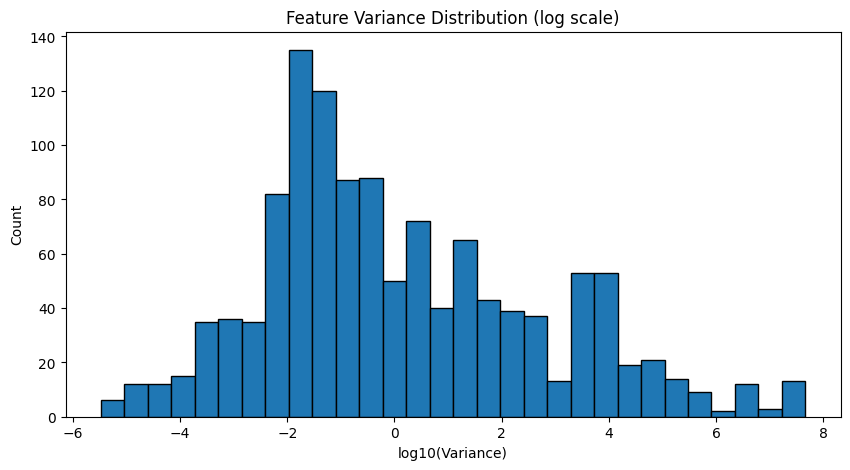

In [15]:
import matplotlib.pyplot as plt

#  Log10 스케일 히스토그램 출력 

log_variances = np.log10(variances)

plt.figure(figsize=(10, 5))
plt.hist(log_variances, bins=30, edgecolor='black')
plt.title("Feature Variance Distribution (log scale)")
plt.xlabel("log10(Variance)")
plt.ylabel("Count")
plt.show()

# 12. 자기 자신을 제외한 Correlation 중 가장 높은 Descriptor 쌍 10개에 대해 scatter plot

Top 10 correlation pairs:
Sp           apol           1.0
SpAbs_A      SpAD_A         1.0
SpMax_Dzare  LogEE_Dzare    1.0
SpAbs_D      SpAD_D         1.0
SpMax_Dzpe   LogEE_Dzpe     1.0
NtCH         StCH           1.0
SpMax_Dzv    LogEE_Dzv      1.0
n12FARing    n12FAHRing     1.0
n7HRing      n7ARing        1.0
             n7AHRing       1.0
dtype: float64


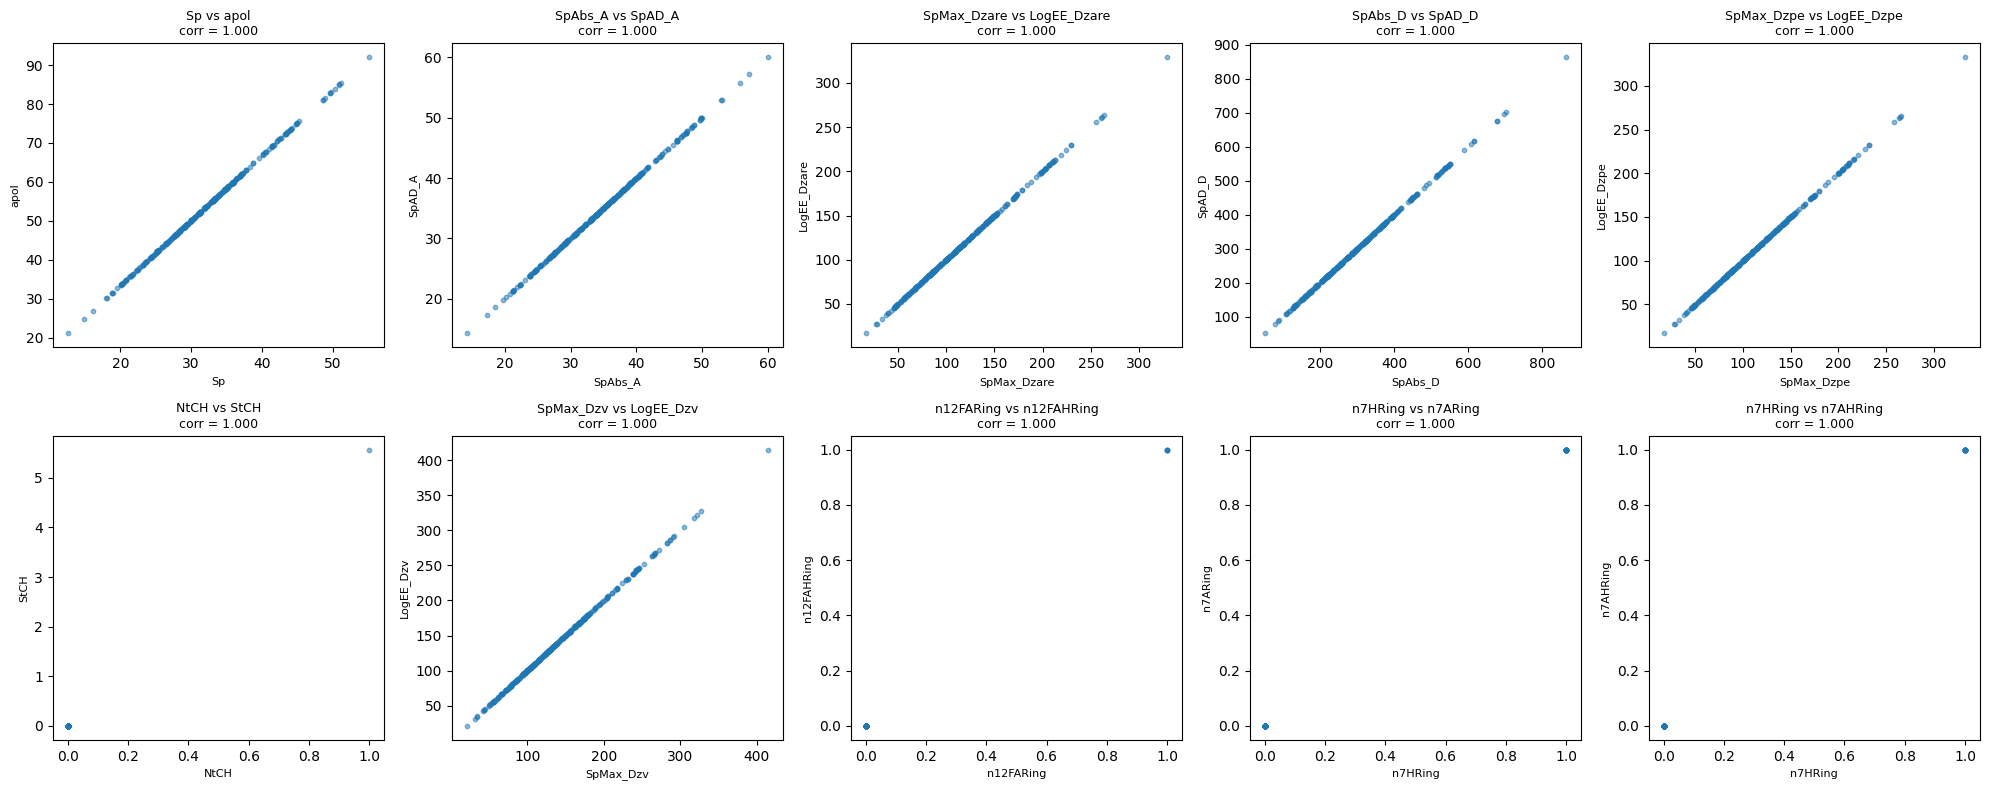

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 상관관계 행렬 계산 (SMILES 컬럼 제외)
corr_matrix = df_step10.drop(columns=['Canonical_Smiles']).corr()

# 중복 계산 방지를 위해 상삼각행렬(Upper Triangle)만 추출 및 스택(Stack)
# 자기 자신과의 상관관계(대각선)를 제외하기 위해 k=1 설정
sol = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)).stack()

# 상관계수 절대값 기준 내림차순 정렬 후 상위 10개 추출
top_10_pairs = sol.sort_values(ascending=False).head(10)

print("Top 10 correlation pairs:")
print(top_10_pairs)

#  시각화 (2행 5열 격자 구성)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ((desc1, desc2), correlation) in enumerate(top_10_pairs.items()):
    axes[i].scatter(df_step10[desc1], df_step10[desc2], alpha=0.5, s=10)
    axes[i].set_title(f"{desc1} vs {desc2}\ncorr = {correlation:.3f}", fontsize=9)
    axes[i].set_xlabel(desc1, fontsize=8)
    axes[i].set_ylabel(desc2, fontsize=8)

plt.tight_layout()
plt.show()

# 13. 자기 자신을 제외한 Correlation 중 가장 낮은 Descriptor 쌍 10개에 대해 scatter plot

Bottom 10 correlation pairs:
SM1_Dzi   nBondsT      7.878480e-07
NsssN     JGI6         9.557063e-07
AATS1d    ATSC0d       1.397399e-06
AATSC6se  Xp-2d        1.657565e-06
AATS6p    VE2_Dzv      2.437002e-06
AATSC6se  VR2_DzZ      2.571609e-06
AATSC7dv  n10FaRing    2.597677e-06
GATS3Z    JGI10        2.599122e-06
AATS5v    ATSC2i       3.013404e-06
MATS3c    VR3_Dzv      3.306350e-06
dtype: float64


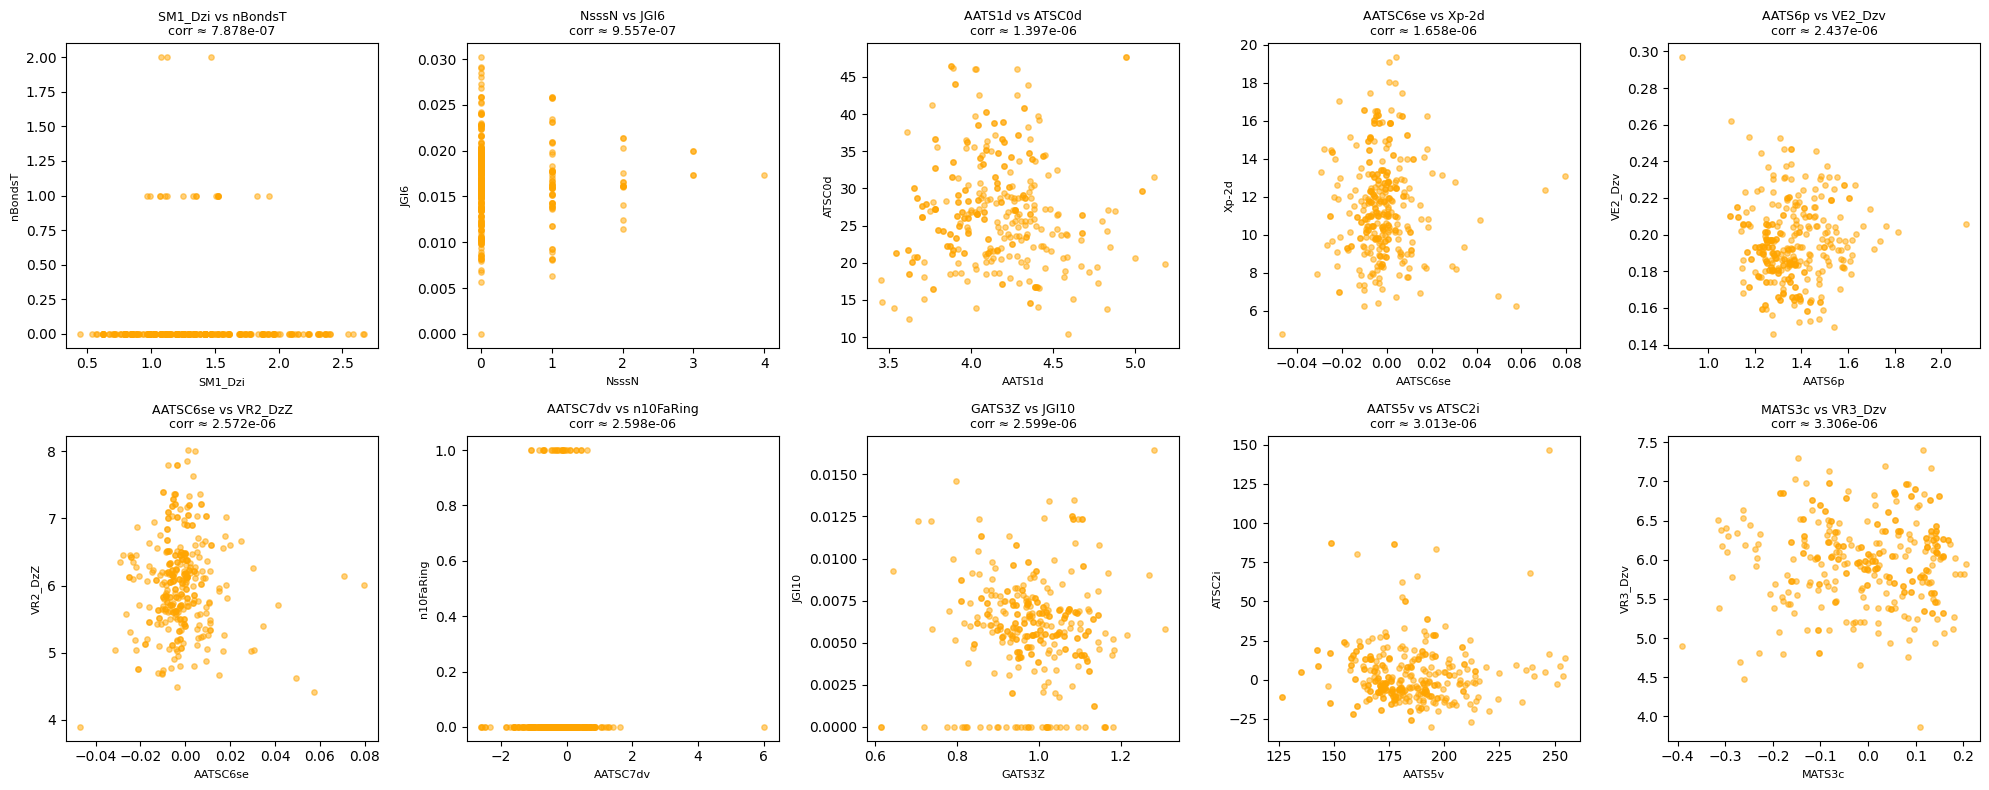

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  상관관계 행렬의 절대값 계산 (0에 가까운 정도를 측정하기 위함)
corr_abs = df_step10.drop(columns=['Canonical_Smiles']).corr().abs()

#  중복 방지를 위해 상삼각행렬만 추출 및 스택
sol_low = corr_abs.where(np.triu(np.ones(corr_abs.shape), k=1).astype(bool)).stack()

# 상관계수 기준 오름차순(가장 낮은 순) 정렬 후 상위 10개 추출
bottom_10_pairs = sol_low.sort_values(ascending=True).head(10)

print("Bottom 10 correlation pairs:")
print(bottom_10_pairs)

# 시각화 (2행 5열 격자 구성)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, ((desc1, desc2), correlation) in enumerate(bottom_10_pairs.items()):
    axes[i].scatter(df_step10[desc1], df_step10[desc2], alpha=0.5, s=15, color='orange')
    axes[i].set_title(f"{desc1} vs {desc2}\ncorr ≈ {correlation:.3e}", fontsize=9)
    axes[i].set_xlabel(desc1, fontsize=8)
    axes[i].set_ylabel(desc2, fontsize=8)

plt.tight_layout()
plt.show()

# 14. Canonical_Smiles, End_Point, Descriptor~~  순으로 dataframe 생성.

In [18]:
import pandas as pd

#  5작업에서 df_final(Smiles, End_Point)과 10에서의 df_step10(Smiles, Descriptors) 병합
# 'Canonical_Smiles' 컬럼을 기준으로 결합합니다.
df_final_combined = pd.merge(df_final[['Canonical_Smiles', 'End_Point']], df_step10, on='Canonical_Smiles')

# 2. 결과 출력
print(f"최종 데이터프레임 크기: {df_final_combined.shape}")
# 컬럼 순서가 Canonical_Smiles, End_Point, Descriptor 확인
df_final_combined.head()

최종 데이터프레임 크기: (341, 1223)


,Canonical_Smiles,End_Point,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,5.000,18.849242,15.034433,0,0,32.077631,2.557420,4.913099,32.077631,...,10.252911,75.234647,312.101111,8.669475,1347,41,132.0,162.0,7.000000,5.416667
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,5.400,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,5.175,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,5.200,16.849242,13.107364,0,0,28.593773,2.405085,4.653779,28.593773,...,9.916848,70.967206,275.117095,8.091679,1050,29,114.0,135.0,4.416667,4.583333
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,5.150,21.965399,18.997252,0,0,37.057961,2.496435,4.862435,37.057961,...,10.184636,80.108735,378.118886,9.002831,2065,41,148.0,176.0,8.000000,6.194444


# 15. 방금 새로 만든 dataframe을 csv 파일로 저장.
### 파일명은 "학번_mordred.csv"

In [19]:
#  최종 데이터프레임을 CSV 파일로 저장
fn_out = "20220536_mordred.csv"

# index=False 옵션을 사용하여 불필요한 행 번호가 저장되지 않게
df_final_combined.to_csv(fn_out, index=False)

# 저장된 파일이 잘 생성되었는지 다시 읽어서 최종 확인
df_check = pd.read_csv(fn_out)

print(f"파일 저장 완료: {fn_out}")
print(f"최종 저장된 데이터프레임 크기: {df_check.shape}")

# 상위 5개 행을 출력하여 데이터 구조 확인
df_check.head()

파일 저장 완료: 20220536_mordred.csv
최종 저장된 데이터프레임 크기: (341, 1223)


,Canonical_Smiles,End_Point,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,5.000,18.849242,15.034433,0,0,32.077631,2.557420,4.913099,32.077631,...,10.252911,75.234647,312.101111,8.669475,1347,41,132.0,162.0,7.000000,5.416667
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,5.400,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,5.175,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,5.200,16.849242,13.107364,0,0,28.593773,2.405085,4.653779,28.593773,...,9.916848,70.967206,275.117095,8.091679,1050,29,114.0,135.0,4.416667,4.583333
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,5.150,21.965399,18.997252,0,0,37.057961,2.496435,4.862435,37.057961,...,10.184636,80.108735,378.118886,9.002831,2065,41,148.0,176.0,8.000000,6.194444


## 파일이 잘 저장되서 아래와 같이 나오는지 확인.

In [20]:
ck = pd.read_csv(fn_out)
ck

,Canonical_Smiles,End_Point,ABC,ABCGG,nAcid,nBase,SpAbs_A,SpMax_A,SpDiam_A,SpAD_A,...,SRW10,TSRW10,MW,AMW,WPath,WPol,Zagreb1,Zagreb2,mZagreb1,mZagreb2
0,C#Cc1cc2c(cc1OC)-c1[nH]nc(-c3ccc(C#N)nc3)c1C2,5.000,18.849242,15.034433,0,0,32.077631,2.557420,4.913099,32.077631,...,10.252911,75.234647,312.101111,8.669475,1347,41,132.0,162.0,7.000000,5.416667
1,C(=C/c1cncc(O[C@@H]2CCNC2)c1)\c1ccncc1,5.400,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
2,C(=C/c1cncc(O[C@H]2CCNC2)c1)\c1ccncc1,5.175,15.556349,12.287328,0,1,26.857729,2.294589,4.567963,26.857729,...,9.545741,65.993788,267.137162,7.219923,937,23,100.0,112.0,4.444444,4.500000
3,C(=N/Nc1nc2ccccc2[nH]1)\c1c[nH]c2ccccc12,5.200,16.849242,13.107364,0,0,28.593773,2.405085,4.653779,28.593773,...,9.916848,70.967206,275.117095,8.091679,1050,29,114.0,135.0,4.416667,4.583333
4,C/C(=N\NC(=O)c1nnn(-c2nonc2N)c1-c1ccccc1)c1ccco1,5.150,21.965399,18.997252,0,0,37.057961,2.496435,4.862435,37.057961,...,10.184636,80.108735,378.118886,9.002831,2065,41,148.0,176.0,8.000000,6.194444
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
336,Oc1nn2ccccc2c1Br,5.550,8.582741,7.975860,0,0,14.227966,2.420131,4.650057,14.227966,...,9.325007,56.046533,211.958525,13.247408,138,15,58.0,69.0,3.694444,2.416667
337,c1ccc(-c2c[nH]c3ncnc(N4CCCCC4)c23)cc1,5.200,16.768362,13.529105,0,0,28.998493,2.498634,4.909236,28.998493,...,10.036225,69.196348,278.153147,7.132132,865,33,114.0,137.0,4.416667,4.638889
338,c1ccc(COc2ccc(Nc3ncnc4ccccc34)cc2)cc1,5.000,19.718110,13.761604,0,0,33.972872,2.389456,4.778912,33.972872,...,10.016682,59.587399,327.137162,7.788980,1764,36,130.0,150.0,5.416667,5.555556
339,c1ccc(CSc2nc(-c3ccncc3)n[nH]2)cc1,5.100,14.808802,11.720375,0,0,25.778444,2.344846,4.575239,25.778444,...,9.556975,65.367861,268.078267,8.647686,811,23,96.0,109.0,4.194444,4.277778
